In [32]:
import cv2
import numpy as np
import math
from google.colab.patches import cv2_imshow
gray_image = cv2.imread('input_image.png', cv2.IMREAD_GRAYSCALE)
gray_image_np = np.array(gray_image)
print(gray_image)
print(gray_image_np.shape)

[[210 212 213 ... 213 207 213]
 [212 213 210 ... 207 208 214]
 [213 216 211 ... 210 211 208]
 ...
 [218 216 211 ... 166 189 169]
 [189 210 221 ... 176 207 207]
 [233 211 216 ... 206 150 216]]
(256, 256)


In [33]:
#scaling
def scaling_using_nearestneighbour(images,scale):
   newimage = np.zeros((images.shape[0]*scale,images.shape[1]*scale))
   for i in range(len(newimage)):
    for j in range(len(newimage[0])):
      newimage[i][j] = images[math.floor(i/scale)][math.floor(j/scale)]
   return newimage
def scaling_using_bilinearinterpolation(images,scale):
   newimage = np.zeros((images.shape[0]*scale,images.shape[1]*scale))
   for i in range(len(newimage)):
     for j in range(len(newimage[0])):
      x_i = i/scale
      x_j = j/scale
      if(0<=x_i<images.shape[0]-1 and 0<=x_j<images.shape[1]-1 ):
        if(int(x_i)!=x_i and int(x_j)!=x_j):
         floorxi = math.floor(x_i)
         ceilxi = math.ceil(x_i)
         floorxj = math.floor(x_j)
         ceilxj = math.ceil(x_j)
         xdist1 = images[floorxi][floorxj]*abs(ceilxi-x_i) + images[ceilxi][floorxj]*abs(floorxi-x_i)
         xdist2 = images[floorxi][ceilxj]*abs(ceilxi-x_i) + images[ceilxi][ceilxj]*abs(floorxi-x_i)
         newimage[i][j] = xdist1*abs(x_j-ceilxj) + xdist2*abs(floorxj-x_j)
        elif(int(x_i)==x_i and int(x_j)!=x_j):
         floorxj = math.floor(x_j)
         ceilxj = math.ceil(x_j)
         newimage[i][j] = images[int(x_i)][floorxj]*abs(x_j-ceilxj) + images[int(x_i)][ceilxj]*abs(floorxj-x_j)
        elif(int(x_i)!=x_i and int(x_j)==x_j):
         floorxi = math.floor(x_i)
         ceilxi = math.ceil(x_i)
         newimage[i][j] = images[floorxi][int(x_j)]*abs(x_i-ceilxi) + images[ceilxi][int(x_j)]*abs(floorxi-x_i)
        elif(int(x_i)==x_i and int(x_j)==x_j):
         newimage[i][j] = images[int(x_i)][int(x_j)]
      elif(images.shape[0]-1<=x_i<images.shape[0] and 0<=x_j<images.shape[1]-1):
         floorxj = math.floor(x_j)
         ceilxj = math.ceil(x_j)
         newimage[i][j] = images[int(x_i)][floorxj]*abs(x_j-ceilxj) + images[int(x_i)][ceilxj]*abs(floorxj-x_j)
      elif(0<=x_i<images.shape[0]-1 and images.shape[1]-1<=x_j<images.shape[1]):
         floorxi = math.floor(x_i)
         ceilxi = math.ceil(x_i)
         newimage[i][j] = images[floorxi][int(x_j)]*abs(x_i-ceilxi) + images[ceilxi][int(x_j)]*abs(floorxi-x_i)
      elif(images.shape[0]-1<=x_i<images.shape[0] and images.shape[1]-1<=x_j<images.shape[1] ):
         newimage[i][j] = images[int(x_i)][int(x_j)]
   return newimage


In [34]:
#rotation
def rotation_using_bilinearinterpolation(images,degree,scale=math.sqrt(2)):
  if(45<=(degree+45)<90):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45))
  elif(90<=(degree+45)<135):
    scale=math.sqrt(2)*np.sin(np.radians(180-degree-45))
  elif(135<=(degree+45)<180):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-90))
  elif(180<=(degree+45)<225):
    scale=math.sqrt(2)*np.sin(np.radians(270-degree-45))
  elif(225<=(degree+45)<270):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-180))
  elif(270<=(degree+45)<315):
    scale=math.sqrt(2)*np.sin(np.radians(360-degree-45))
  elif(315<=(degree+45)<360):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-270))
  elif(360<=(degree+45)<405):
    scale=math.sqrt(2)*np.sin(np.radians(450-degree-45))
  newimage = np.zeros((math.floor(images.shape[0]*scale),math.floor(images.shape[1]*scale)))
  c_x = int(images.shape[1]/2)
  c_y = int(images.shape[0]/2)
  newc_x = int(newimage.shape[1]/2)
  newc_y = int(newimage.shape[0]/2)
  for i in range(len(newimage)):
    for j in range(len(newimage[0])):
      y = i-newc_y
      x = j-newc_x
      x_j = x*np.cos(np.radians(degree))-1*np.sin(np.radians(degree))*y
      x_i = x*np.sin(np.radians(degree))+y*np.cos(np.radians(degree))
      x_j += c_x
      x_i += c_y
      if(0<x_j<images.shape[1]-1 and 0<x_i<images.shape[0]-1 ):
       if(int(x_i)!=x_i and int(x_j)!=x_j):
         floorxi = math.floor(x_i)
         ceilxi = math.ceil(x_i)
         floorxj = math.floor(x_j)
         ceilxj = math.ceil(x_j)
         xdist1 = images[floorxi][floorxj]*abs(ceilxi-x_i) + images[ceilxi][floorxj]*abs(floorxi-x_i)
         xdist2 = images[floorxi][ceilxj]*abs(ceilxi-x_i) + images[ceilxi][ceilxj]*abs(floorxi-x_i)
         newimage[i][j] = xdist1*abs(x_j-ceilxj) + xdist2*abs(floorxj-x_j)
       elif(int(x_i)==x_i and int(x_j)!=x_j):
        floorxj = math.floor(x_j)
        ceilxj = math.ceil(x_j)
        newimage[i][j] = images[int(x_i)][floorxj]*abs(x_j-ceilxj) + images[int(x_i)][ceilxj]*abs(floorxj-x_j)
       elif(int(x_i)!=x_i and int(x_j)==x_j):
        floorxi = math.floor(x_i)
        ceilxi = math.ceil(x_i)
        newimage[i][j] = images[floorxi][int(x_j)]*abs(x_i-ceilxi) + images[ceilxi][int(x_j)]*abs(floorxi-x_i)
       elif(int(x_i)==x_i and int(x_j)==x_j):
        newimage[i][j] = images[int(x_i)][int(x_j)]
  return newimage
def rotation_using_nearestneighbour(images,degree):
  if(45<=(degree+45)<90):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45))
  elif(90<=(degree+45)<135):
    scale=math.sqrt(2)*np.sin(np.radians(180-degree-45))
  elif(135<=(degree+45)<180):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-90))
  elif(180<=(degree+45)<225):
    scale=math.sqrt(2)*np.sin(np.radians(270-degree-45))
  elif(225<=(degree+45)<270):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-180))
  elif(270<=(degree+45)<315):
    scale=math.sqrt(2)*np.sin(np.radians(360-degree-45))
  elif(315<=(degree+45)<360):
    scale=math.sqrt(2)*np.sin(np.radians(degree+45-270))
  elif(360<=(degree+45)<405):
    scale=math.sqrt(2)*np.sin(np.radians(450-degree-45))
  newimage = np.zeros((math.floor(images.shape[0]*scale),math.floor(images.shape[1]*scale)))
  c_x = int(images.shape[1]/2)
  c_y = int(images.shape[0]/2)
  newc_x = int(newimage.shape[1]/2)
  newc_y = int(newimage.shape[0]/2)
  for i in range(len(newimage)):
    for j in range(len(newimage[0])):
      y = i-newc_y
      x = j-newc_x
      x_j = x*np.cos(np.radians(degree))-1*np.sin(np.radians(degree))*y
      x_i = x*np.sin(np.radians(degree))+y*np.cos(np.radians(degree))
      x_j += c_x
      x_i += c_y
      if(0<x_j<images.shape[1] and 0<x_i<images.shape[0] ):
       newimage[i][j] = images[math.floor(x_i)][math.floor(x_j)]
  return newimage

In [35]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = "/content/drive/MyDrive/Scaled_Images_final"
os.makedirs(save_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


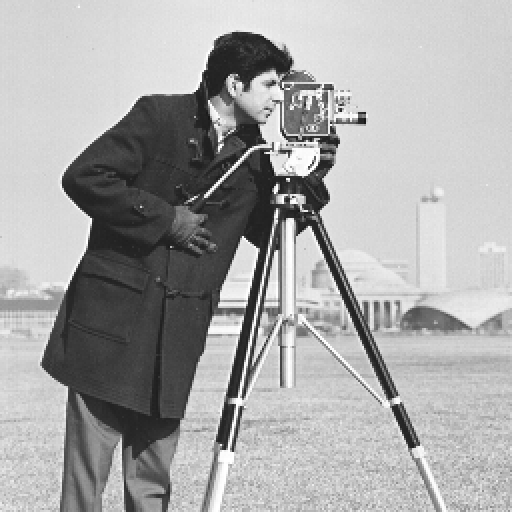

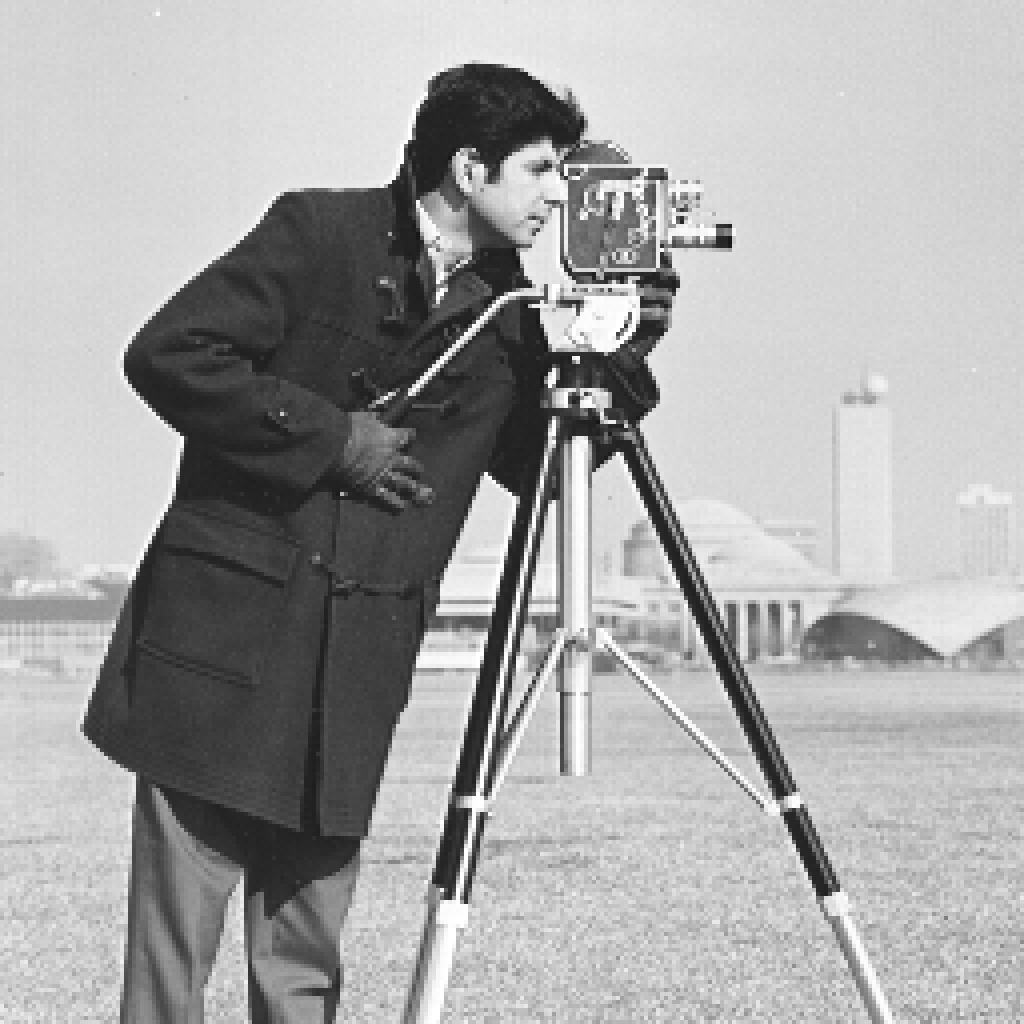

In [36]:
image_scale_nearestneighbour = scaling_using_nearestneighbour(gray_image_np,2)
cv2_imshow(image_scale_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "scale_2_nearestneighbour.png"), image_scale_nearestneighbour)
print(" ")
image_scale_nearestneighbour = scaling_using_nearestneighbour(gray_image_np,4)
cv2_imshow(image_scale_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "scale_4_nearestneighbour.png"), image_scale_nearestneighbour)
print(" ")

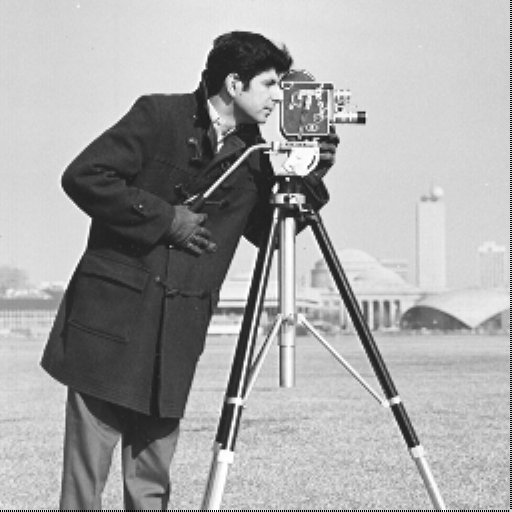

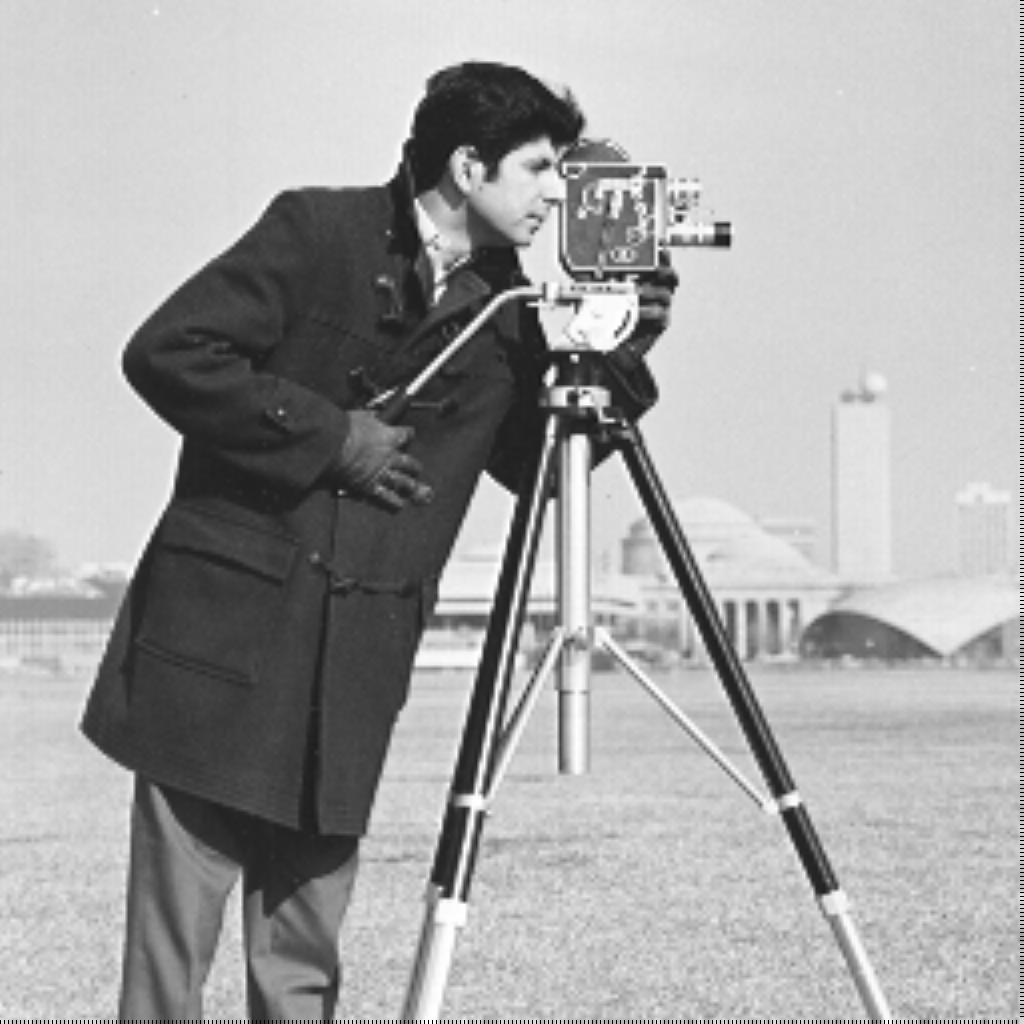

In [37]:
image_scale_bilinearinterpolation = scaling_using_bilinearinterpolation(gray_image_np,2)
cv2_imshow(image_scale_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "scale_2_bilinear.png"), image_scale_bilinearinterpolation)
print(" ")
image_scale_bilinearinterpolation = scaling_using_bilinearinterpolation(gray_image_np,4)
cv2_imshow(image_scale_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "scale_4_bilinear.png"), image_scale_bilinearinterpolation)
print(" ")

In [38]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = "/content/drive/MyDrive/Rotated_Images_final"
os.makedirs(save_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


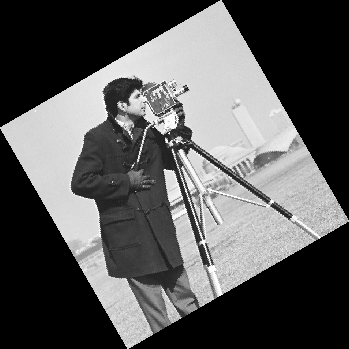

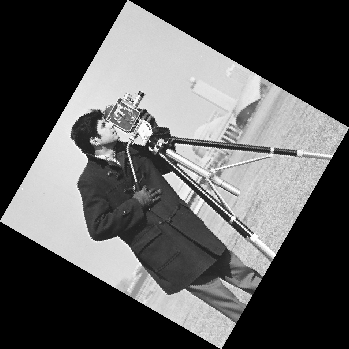

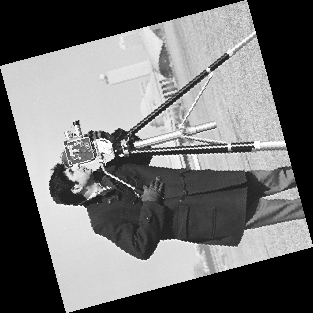

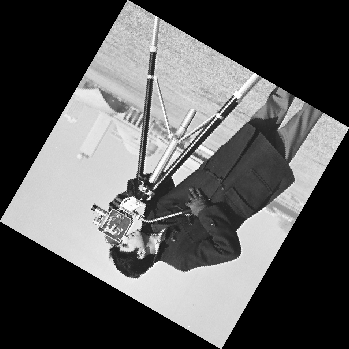

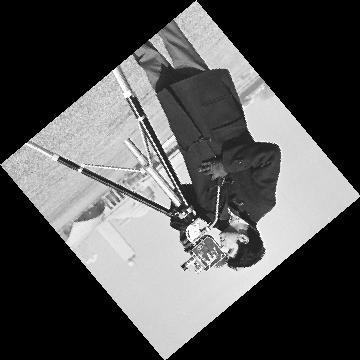

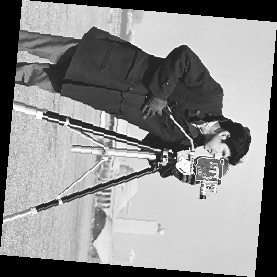

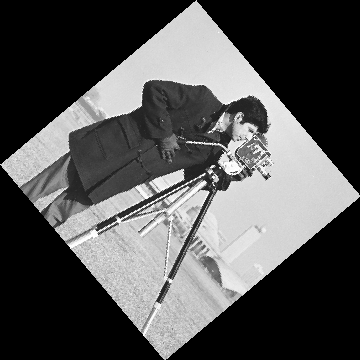

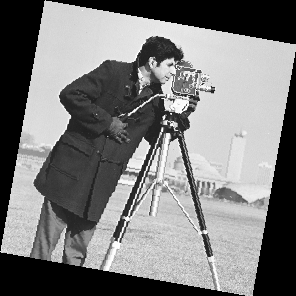

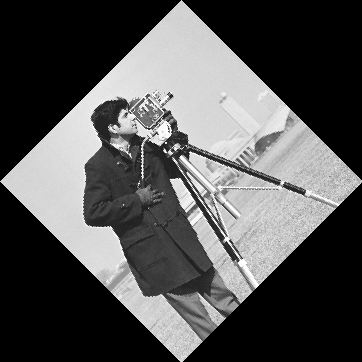

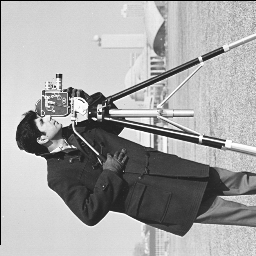

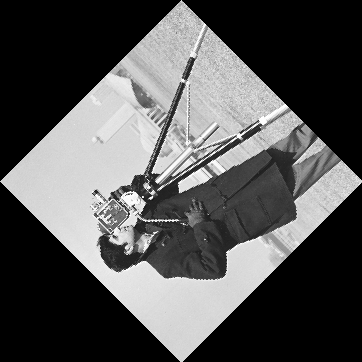

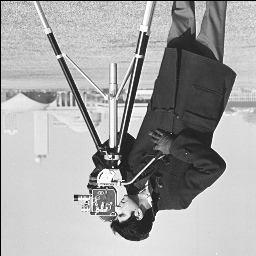

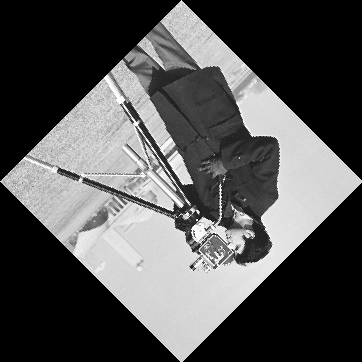

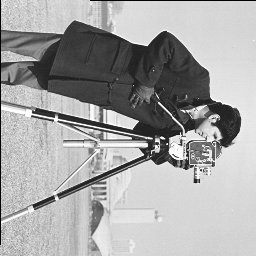

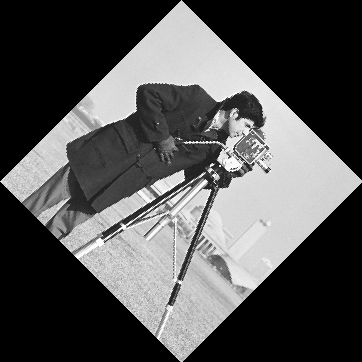

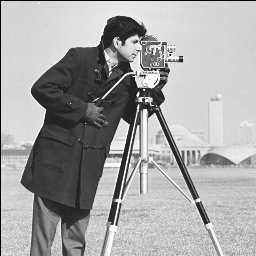

True

In [39]:
image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,30)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_30_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,60)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_60_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,105)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_105_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,150)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_150_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,220)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_220_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,265)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_265_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,310)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_310_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,350)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_350_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,45)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_45_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,90)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_90_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,135)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_135_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,180)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_180_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,225)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_225_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,270)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_270_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,315)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_315_nearestneighbour.png"), image_rotate_nearestneighbour)
print(" ")

image_rotate_nearestneighbour = rotation_using_nearestneighbour(gray_image_np,0)
cv2_imshow(image_rotate_nearestneighbour)
cv2.imwrite(os.path.join(save_dir, "rotate_0_nearestneighbour.png"), image_rotate_nearestneighbour)

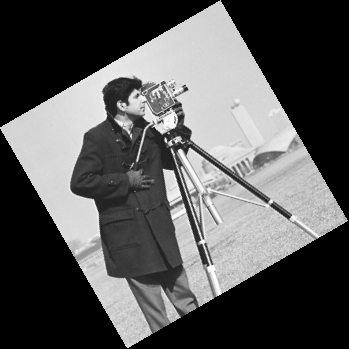

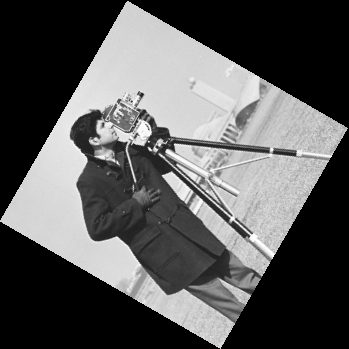

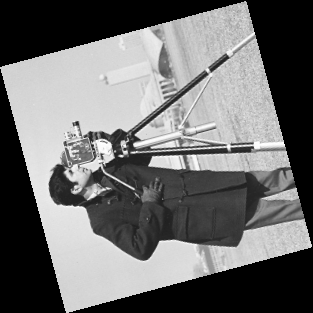

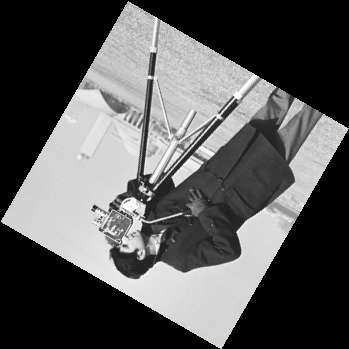

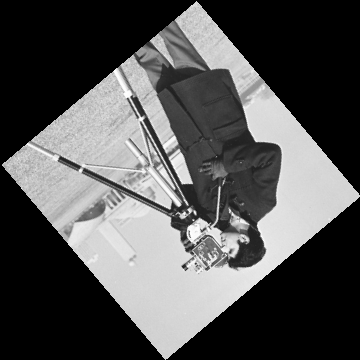

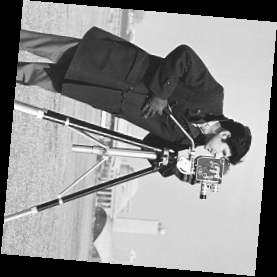

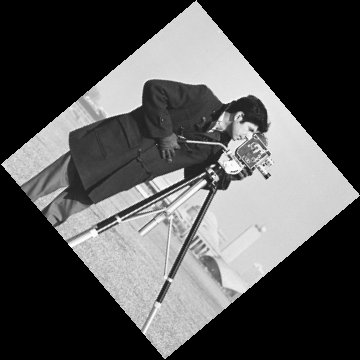

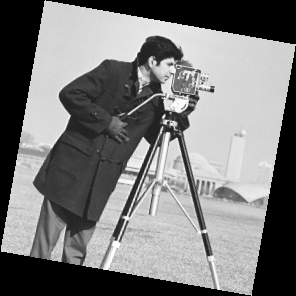

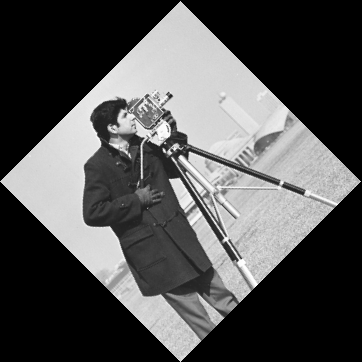

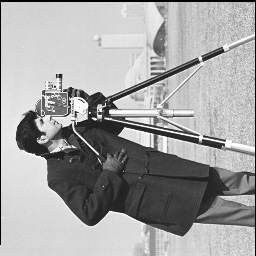

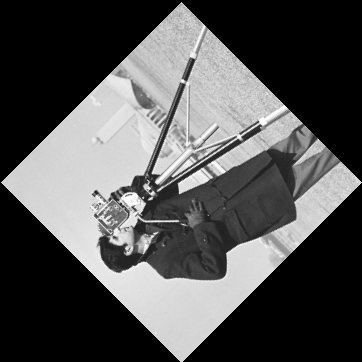

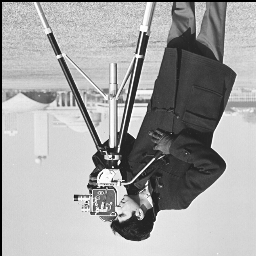

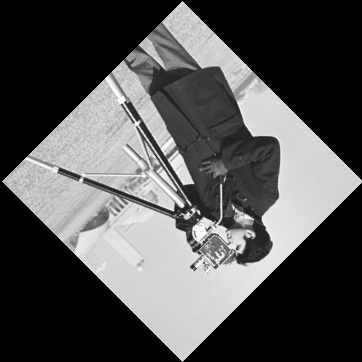

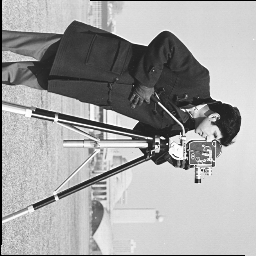

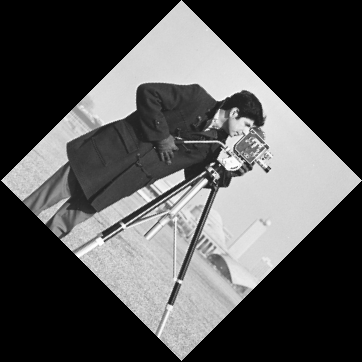

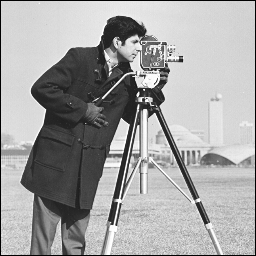

True

In [40]:


image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,30)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_30_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,60)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_60_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,105)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_105_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,150)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_150_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,220)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_220_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,265)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_265_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,310)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_310_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,350)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_350_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,45)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_45_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,90)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_90_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,135)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_135_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,180)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_180_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,225)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_225_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,270)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_270_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,315)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_315_bilinear.png"), image_rotate_bilinearinterpolation)
print(" ")

image_rotate_bilinearinterpolation = rotation_using_bilinearinterpolation(gray_image_np,0)
cv2_imshow(image_rotate_bilinearinterpolation)
cv2.imwrite(os.path.join(save_dir, "rotate_0_bilinear.png"), image_rotate_bilinearinterpolation)